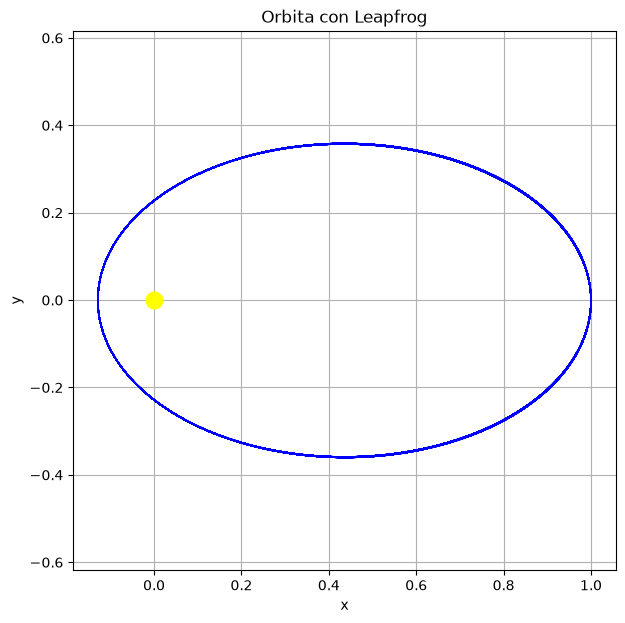

In [2]:

import numpy as np
import matplotlib.pyplot as plt


# Parámetros
G = 4.0 * np.pi**2
M = 1.0

t_0 = 0.0
t_f = 20.0
n = 500000
h = (t_f - t_0) / n

t = np.linspace(t_0, t_f, n)
Q = np.zeros((n, 4))


# CONDICIONES INICIALES (x, y, vx, vy)

Q[0, 0] = 1.0
Q[0, 1] = 0.0
Q[0, 2] = 0.0
Q[0, 3] = 3.0


# LEAPFROG 
r2_0 = Q[0, 0]**2 + Q[0, 1]**2
ax0 = -G * M * Q[0, 0] / (r2_0**(3/2))
ay0 = -G * M * Q[0, 1] / (r2_0**(3/2))

Q[0, 2] = Q[0, 2] - h * ax0
Q[0, 3] = Q[0, 3] - h * ay0


# INTEGRACIÓN

i = 1
while i < n:
    # Aceleraciones en el punto actual (i - 1)
    r2 = Q[i - 1, 0]**2 + Q[i - 1, 1]**2
    ax = -G * M * Q[i - 1, 0] / (r2**(3/2))
    ay = -G * M * Q[i - 1, 1] / (r2**(3/2))
    
    # Actualizacion de velocidades
    Q[i, 2] = Q[i - 1, 2] + 2.0 * h * ax
    Q[i, 3] = Q[i - 1, 3] + 2.0 * h * ay
    
    # Actualizacion de posiciones
    Q[i, 0] = Q[i - 1, 0] + 2.0 * h * Q[i, 2]
    Q[i, 1] = Q[i - 1, 1] + 2.0 * h * Q[i, 3]
    
    i = i + 1


# GRAFICA

plt.figure(figsize=(7, 7))
plt.plot(Q[:, 0], Q[:, 1], color='blue', linewidth=1)
plt.plot(0, 0, marker='o', color='yellow', markersize=12)
plt.title("Orbita con Leapfrog")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis('equal')
plt.show()